In [17]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import argparse
import os
from pathlib import Path
import json
import re
import numpy as np
import importlib
from typing import Callable, Any
OUTPUT_DIR = "results-bcra/paper_graphics"



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:

ALGORITHMS = {}
ALGORITHMS['cryptography'] = {
    'ecdsa': {
        1: 'P-256',
        3: 'P-384',
        5: 'P-521'
    },
}

ALGORITHMS['liboqs'] =  {
    'mldsa': {
        1: 'ML-DSA-44',
        2: 'ML-DSA-44',
        3: 'ML-DSA-65',
        5: 'ML-DSA-87'
    },
    'dilithium': {
        1: 'Dilithium2',
        2: 'Dilithium2',
        3: 'Dilithium3',
        5: 'Dilithium5'
    },
    'sphincs-sha-s': {
        1: 'SPHINCS+-SHA2-128s-simple',
        3: 'SPHINCS+-SHA2-192s-simple',
        5: 'SPHINCS+-SHA2-256s-simple'
    },
    'sphincs-sha-f': {
        1: 'SPHINCS+-SHA2-128f-simple',
        3: 'SPHINCS+-SHA2-192f-simple',
        5: 'SPHINCS+-SHA2-256f-simple'
    },
    'sphincs-shake-s': {
        1: 'SPHINCS+-SHAKE-128s-simple',
        3: 'SPHINCS+-SHAKE-192s-simple',
        5: 'SPHINCS+-SHAKE-256s-simple'
    },
    'sphincs-shake-f': {
        1: 'SPHINCS+-SHAKE-128f-simple',
        3: 'SPHINCS+-SHAKE-192f-simple',
        5: 'SPHINCS+-SHAKE-256f-simple'
    },
    'falcon': {
        1: 'Falcon-512',
        5: 'Falcon-1024'
    },
    'falcon-padded': {
        1: 'Falcon-padded-512',
        5: 'Falcon-padded-1024'
    },
    'mayo': {
        1: 'MAYO-2',
        3: 'MAYO-3',
        5: 'MAYO-5'
    },
    'cross-rsdp-small': {
        1: 'cross-rsdp-128-small',
        3: 'cross-rsdp-192-small',
        5: 'cross-rsdp-256-small'
    },
    'cross-rsdpg-small': {
        1: 'cross-rsdpg-128-small',
        3: 'cross-rsdpg-192-small',
        5: 'cross-rsdpg-256-small'
    },
    'cross-rsdp-balanced': {
        1: 'cross-rsdp-128-balanced',
        3: 'cross-rsdp-192-balanced',
        5: 'cross-rsdp-256-balanced'
    },
    'cross-rsdpg-balanced': {
        1: 'cross-rsdpg-128-balanced',
        3: 'cross-rsdpg-192-balanced',
        5: 'cross-rsdpg-256-balanced'
    },
    'cross-rsdp-fast': {
        1: 'cross-rsdp-128-fast',
        3: 'cross-rsdp-192-fast',
        5: 'cross-rsdp-256-fast'
    },
    'cross-rsdpg-fast': {
        1: 'cross-rsdpg-128-fast',
        3: 'cross-rsdpg-192-fast',
        5: 'cross-rsdpg-256-fast'
    }
}


In [19]:
def ensure_output_dir(output_dir):
    """
    Checks if OUTPUT_DIR exists, and creates it if not.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
    else:
        print(f"Directory already exists: {output_dir}")

ensure_output_dir(OUTPUT_DIR)

Created directory: results-bcra/paper_graphics


In [20]:
def find_csv_recursive(root_dir, filename):
    """
    Recursively search for a file named `filename` in `root_dir`.
    Returns the full path if found, else None.
    """
    for dirpath, _, files in os.walk(root_dir):
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

def load_results(input_dir,  index_col="variant"):
    """
    Loads CSV data from each subdirectory in input_dir.
    Returns a dictionary:
    {
        'subdir_name': {
            'time-evaluation-tmean-std': pd.DataFrame,
            'blocksim-mean-std': pd.DataFrame
        },
        ...
    }
    """
    results = {}
    colunas_em_bytes = [
        'mean_artifacts_size', 
        'std_artifacts_size',
    ]
    for subdir in os.listdir(input_dir):
        subdir_path = os.path.join(input_dir, subdir)
        if os.path.isdir(subdir_path):
            data = {}
            for key in ['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std']:
                csv_path = find_csv_recursive(subdir_path, f"{key}.csv")
                if csv_path:
                    df = pd.read_csv(csv_path, index_col=index_col)
                    
                    colunas_presentes = [col for col in colunas_em_bytes if col in df.columns]
                    df[colunas_presentes] = df[colunas_presentes] / 1024
                    
                    data[key] = df
                else:
                    data[key] = None  # or pd.DataFrame() if preferred
            results[subdir] = data
    return results

results = load_results("results-bcra")
print(results)  # Print the keys to verify loading


{'scenario1': {'blocksim-model-2-mean-std':                             mean_verify  std_verify  mean_artifacts_size  \
variant                                                                    
Dilithium2                     4.266674    0.101975           303.073949   
Dilithium3                    10.065429    0.281850           411.705522   
Dilithium5                    10.626839    0.303377           580.755205   
Falcon-1024                   16.476808    0.488027           161.645728   
Falcon-512                     9.490988    0.315046            83.862539   
Falcon-padded-1024            13.837221    0.321975           162.162203   
Falcon-padded-512              7.821732    0.114590            84.228898   
MAYO-2                         3.432678    0.055939            22.807335   
MAYO-3                        13.368505    0.312620            73.193690   
MAYO-5                        26.661085    0.402681           106.173404   
ML-DSA-44                      4.675750    0

In [21]:
def get_variants_by_level(df, variant_dict):
    csv_variants = set(df.index.to_list())
    print("CSV Variants:", csv_variants)
    variants_by_level = {}

    for algorithm, levels in variant_dict.items():
        for level, variant in levels.items():
            if variant in csv_variants:
                variants_by_level.setdefault(level, []).append({
                    "algorithm": algorithm,
                    "variant": variant
                })
             
    return dict(sorted(variants_by_level.items()))

def filter_algorithms(algorithms: dict, selected_algorithms: list = None, selected_levels: list = None) -> dict:
    selected_algorithms = selected_algorithms or []
    selected_levels = selected_levels or []

    filtered = {}

    for module, algos in algorithms.items():
        for algorithm, variants in algos.items():
            if selected_algorithms and algorithm not in selected_algorithms:
                continue

            selected_variants = {
                level: name for level, name in variants.items()
                if not selected_levels or level in selected_levels
            }

            if selected_variants:
                filtered.setdefault(module, {})[algorithm] = selected_variants

    return filtered


In [22]:
def algorithm_to_label(algorithm):
    mapping = {
        'ecdsa': 'ECDSA',
        'mldsa': 'ML-DSA',
        'dilithium': 'Dilithium',
        'sphincs-sha-s': 'SPHINCS+-SHA-s',
        'sphincs-sha-f': 'SPHINCS+-SHA-f',
        'sphincs-shake-s': 'SPHINCS+-SHAKE-s',
        'sphincs-shake-f': 'SPHINCS+-SHAKE-f',
        'falcon': 'Falcon',
        'falcon-padded': 'Falcon-padded',
        'mayo': 'MAYO',
        'cross-rsdp-small': 'CROSS-RSDP-small',
        'cross-rsdpg-small': 'CROSS-RSDPG-small',
        'cross-rsdp-balanced': 'CROSS-RSDP-balanced',
        'cross-rsdpg-balanced': 'CROSS-RSDPG-balanced',
        'cross-rsdp-fast': 'CROSS-RSDP-fast',
        'cross-rsdpg-fast': 'CROSS-RSDPG-fast'
    }
    return mapping.get(algorithm, algorithm)

In [23]:
def plot_horizontal_multiple_inverted(
    dfs,                # lista de DataFrames
    columns,
    graphics_directory,
    values_offset,
    error_offset,
    levels=None,        # levels (optional)
    xscale="linear",
    xlabel=None,
    xlim=None,
    xticks=None,
    yticklabels="operation",  # Operations on Y-axis
    figsize=None,
    width=0.7,
    titles=None,        # titles (optional)
    ylabel=None,
    show_graph=False,
    show_values=True,
    show_errors=True,
    show_legend=True,
    save_formats=("pdf", "png"),
    file_name="multiples",
    pallet_start=0,
    legend_location="center left"
):
    """
    Plots multiple horizontal graphs (one per DataFrame).
    Bars represent operations grouped by algorithm.
    """
    n_plots = len(dfs)
    fig, axes = plt.subplots(1, 1, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    fontsize = 18 
    
    for idx, df in enumerate(dfs):
        # Get list of unique algorithms
        algorithms = df['algorithm'].unique()
        n_algorithms = len(algorithms)
        n_operations = len(columns) 
        
        width_bar = width / n_algorithms
        y = np.arange(n_operations)
        ax = axes[idx]
        palette = sns.color_palette("muted", n_colors=len(algorithms) + pallet_start)
        
        max_x_value = 0
        
        for algo_idx, algorithm in enumerate(algorithms):
            color = palette[algo_idx + pallet_start]
            
            # Finding the data for this algorithm
            algo_data = df[df['algorithm'] == algorithm]
            if len(algo_data) == 0:
                continue
                
            # Collect values ​​for all operations of this algorithm.
            values = []
            errors = []
            operation_labels = []
            print(columns)
             
            for i, (val_col, err_col, label) in enumerate(columns):
                if len(algo_data) > 0:
                    val = algo_data[val_col].iloc[0]
                    err = algo_data[err_col].iloc[0] if err_col in algo_data else 0
                    values.append(val)
                    errors.append(err)
                    operation_labels.append(label)
                    
                    if val + err > max_x_value:
                        max_x_value = val + err

            bars = ax.barh(
                y + ((n_algorithms - 1 - algo_idx) - (n_algorithms - 1) / 2) * width_bar,
                values,
                height=width_bar,
                xerr=errors if show_errors else None,
                label= algorithm_to_label(algorithm),  # Label is the name of the algorithm.
                color=color,
                error_kw={"capsize": 3, "ecolor": "red", "elinewidth": 2}
            )

            if show_values:
                for bar, value, err in zip(bars, values, errors):
                    if value == 0 or np.isnan(value): 
                        ax.text(
                            values_offset,
                            bar.get_y() + bar.get_height() / 2,
                            "N/A",
                            va="center",
                            ha="left",
                            fontsize=fontsize-4,
                            color="black",
                            clip_on=False
                        )
                    else:
                        x_pos = value + (err if show_errors else 0) + values_offset
                        ax.text(
                            x_pos,
                            bar.get_y() + bar.get_height() / 2,
                            f"{value:.2f}",
                            va="center",
                            ha="left",
                            fontsize=fontsize-5,
                            color="black",
                            clip_on=False
                        )

        # Configure Y-axis labels with operation names.
        ax.set_yticks(y)
        operation_names = [col[2] for col in columns]
        ax.set_yticklabels(operation_names, rotation=90, va="center", fontsize=fontsize)

        if ylabel:
            ax.set_ylabel(ylabel, fontsize=fontsize)
        if xlabel:
            ax.set_xlabel(xlabel, fontsize=fontsize)
        if titles and idx < len(titles):
            ax.set_title(titles[idx], fontsize=fontsize+50)

        ax.set_xscale(xscale)
        if xscale == "log" and xticks is not None:
            ax.set_xticks(xticks)
        if xscale == "linear":
            if xlim is not None and xlim[1] is not None:
                ax.set_xlim(*xlim)
            else:
                # If it doesn't receive a xlim, add 15% extra space on the right to fit the text.
                ax.set_xlim(0, max_x_value * 1.15)
        
        if len(y) > 0:
            ax.set_ylim(y[0] - 0.5, y[-1] + 0.5)
        
        ax.tick_params(axis="y", labelsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        
        if show_legend:
            ax.legend(
                loc="upper center",
                bbox_to_anchor=(0.5, -0.25), 
                ncol=4,
                fontsize=fontsize-2,
                frameon=True,
                borderpad=0.8,
                handletextpad=0.5,
                columnspacing=1.2
            )
        ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    
    for ext in save_formats:
        file = f"{graphics_directory}/{file_name}.{ext}"
        plt.savefig(file, format=ext, bbox_inches='tight')
        print(f"Saved: {file}")

    if show_graph:
        plt.show()
    plt.close()

All algorithms loaded: ['cryptography', 'liboqs']
Filtered algorithms: {'cryptography': {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}}, 'liboqs': {'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'falcon-padded': {1: 'Falcon-padded-512', 5: 'Falcon-padded-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}}
Combined mechanisms: {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}, 'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'falcon-padded': {1: 'Falcon-padded-512', 5: 'Falcon-padded-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}
Processing results for scenario1: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for scenario2: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for scenario3: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for paper_graphics: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
All algorithms loaded: ['cryptogr

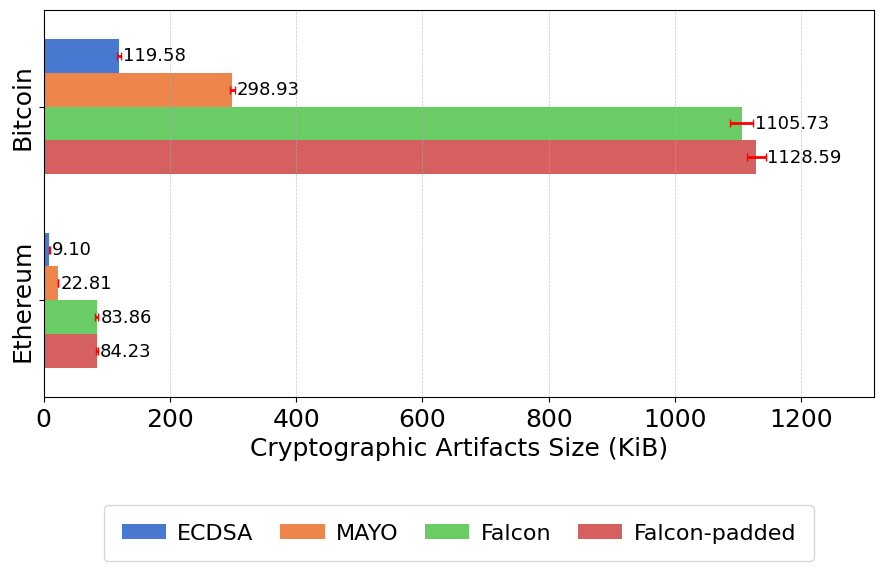

	Processing level 3 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-384'}, {'algorithm': 'mayo', 'variant': 'MAYO-3'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Saved: results-bcra/paper_graphics/sim_scenario1_level-3.pdf


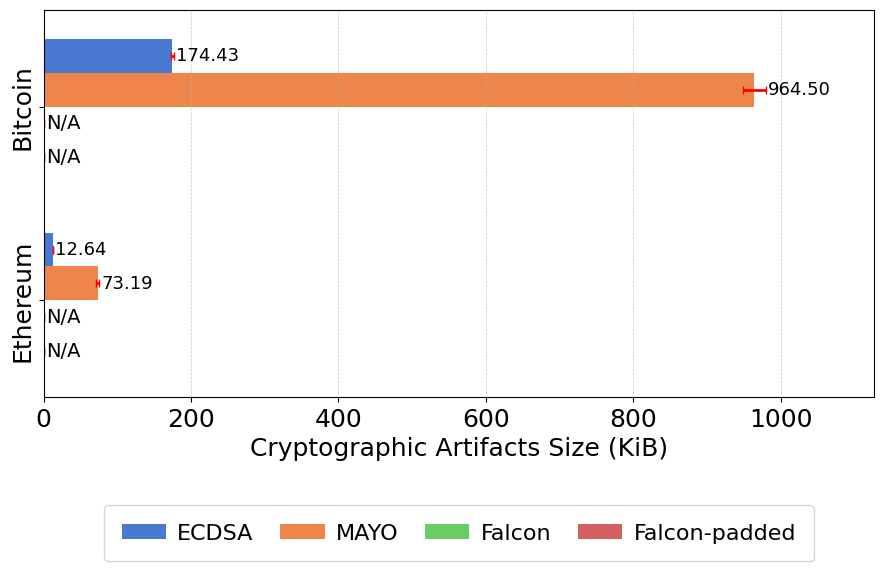

	Processing level 5 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-521'}, {'algorithm': 'falcon', 'variant': 'Falcon-1024'}, {'algorithm': 'falcon-padded', 'variant': 'Falcon-padded-1024'}, {'algorithm': 'mayo', 'variant': 'MAYO-5'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Saved: results-bcra/paper_graphics/sim_scenario1_level-5.pdf


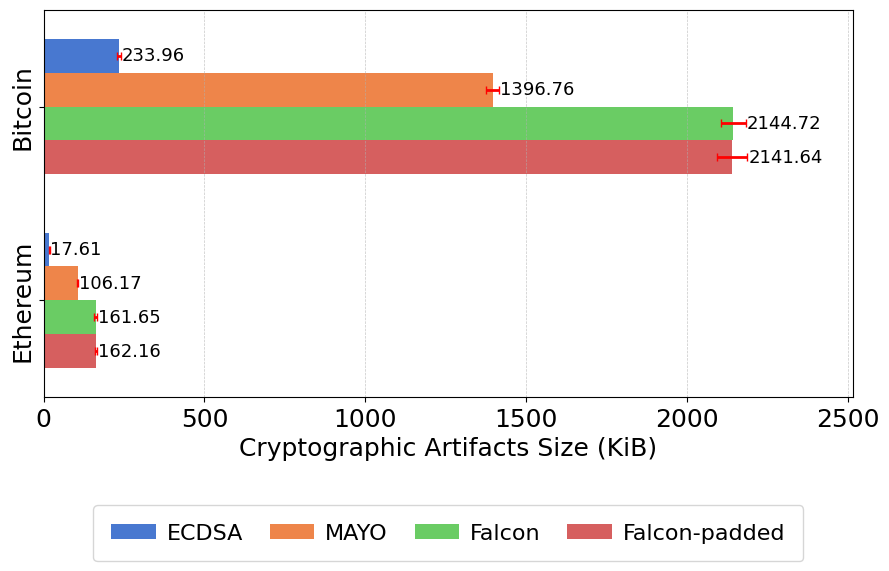

CSV Variants: {'Dilithium2', 'cross-rsdpg-128-fast', 'Dilithium5', 'Falcon-padded-1024', 'cross-rsdp-128-small', 'cross-rsdp-256-small', 'cross-rsdpg-256-fast', 'cross-rsdpg-256-small', 'Falcon-1024', 'cross-rsdpg-192-small', 'SPHINCS+-SHAKE-256f-simple', 'SPHINCS+-SHA2-128s-simple', 'SPHINCS+-SHA2-192s-simple', 'SPHINCS+-SHAKE-128s-simple', 'cross-rsdp-192-fast', 'SPHINCS+-SHA2-256f-simple', 'cross-rsdpg-128-balanced', 'SPHINCS+-SHA2-128f-simple', 'SPHINCS+-SHA2-192f-simple', 'MAYO-5', 'Falcon-padded-512', 'SPHINCS+-SHA2-256s-simple', 'cross-rsdpg-192-balanced', 'ML-DSA-87', 'cross-rsdp-128-fast', 'cross-rsdp-192-balanced', 'SPHINCS+-SHAKE-128f-simple', 'SPHINCS+-SHAKE-192s-simple', 'Falcon-512', 'cross-rsdp-192-small', 'P-384', 'cross-rsdpg-256-balanced', 'P-256', 'cross-rsdpg-128-small', 'MAYO-3', 'Dilithium3', 'cross-rsdp-128-balanced', 'ML-DSA-44', 'MAYO-2', 'SPHINCS+-SHAKE-256s-simple', 'ML-DSA-65', 'cross-rsdp-256-fast', 'cross-rsdp-256-balanced', 'SPHINCS+-SHAKE-192f-simple', '

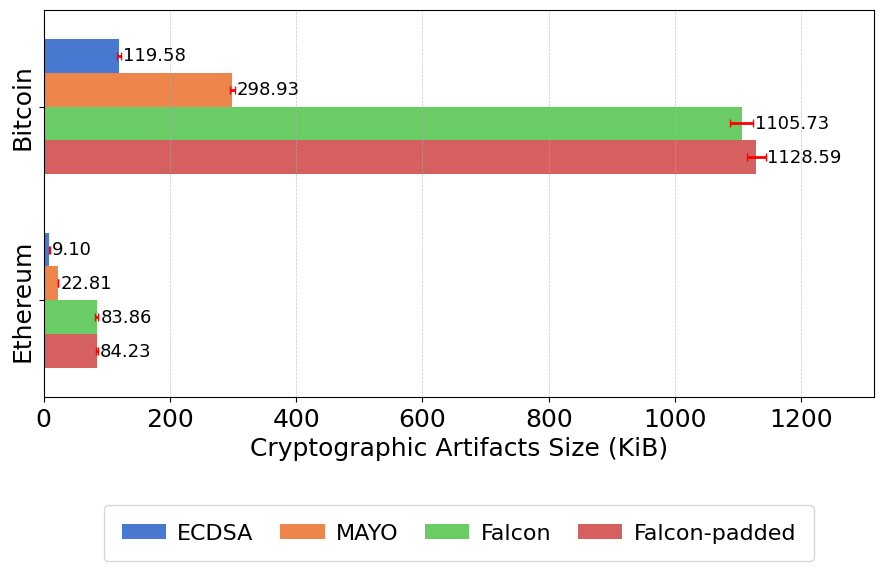

	Processing level 3 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-384'}, {'algorithm': 'mayo', 'variant': 'MAYO-3'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Saved: results-bcra/paper_graphics/sim_scenario2_level-3.pdf


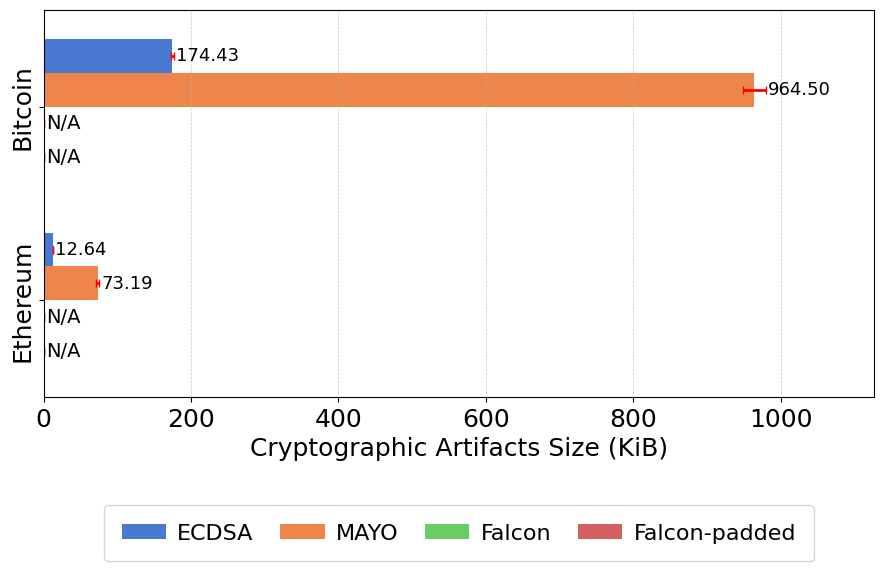

	Processing level 5 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-521'}, {'algorithm': 'falcon', 'variant': 'Falcon-1024'}, {'algorithm': 'falcon-padded', 'variant': 'Falcon-padded-1024'}, {'algorithm': 'mayo', 'variant': 'MAYO-5'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Saved: results-bcra/paper_graphics/sim_scenario2_level-5.pdf


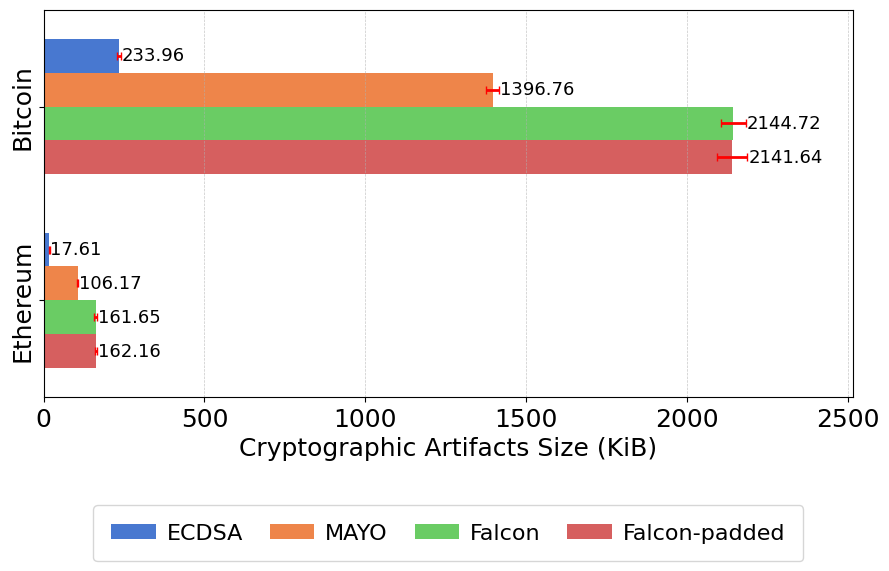

CSV Variants: {'Dilithium2', 'cross-rsdpg-128-fast', 'Dilithium5', 'Falcon-padded-1024', 'cross-rsdp-128-small', 'cross-rsdp-256-small', 'cross-rsdpg-256-fast', 'cross-rsdpg-256-small', 'Falcon-1024', 'cross-rsdpg-192-small', 'SPHINCS+-SHAKE-256f-simple', 'SPHINCS+-SHA2-128s-simple', 'SPHINCS+-SHA2-192s-simple', 'SPHINCS+-SHAKE-128s-simple', 'cross-rsdp-192-fast', 'SPHINCS+-SHA2-256f-simple', 'cross-rsdpg-128-balanced', 'SPHINCS+-SHA2-128f-simple', 'SPHINCS+-SHA2-192f-simple', 'MAYO-5', 'Falcon-padded-512', 'SPHINCS+-SHA2-256s-simple', 'cross-rsdpg-192-balanced', 'ML-DSA-87', 'cross-rsdp-128-fast', 'cross-rsdp-192-balanced', 'SPHINCS+-SHAKE-128f-simple', 'SPHINCS+-SHAKE-192s-simple', 'Falcon-512', 'cross-rsdp-192-small', 'P-384', 'cross-rsdpg-256-balanced', 'P-256', 'cross-rsdpg-128-small', 'MAYO-3', 'Dilithium3', 'cross-rsdp-128-balanced', 'ML-DSA-44', 'MAYO-2', 'SPHINCS+-SHAKE-256s-simple', 'ML-DSA-65', 'cross-rsdp-256-fast', 'cross-rsdp-256-balanced', 'SPHINCS+-SHAKE-192f-simple', '

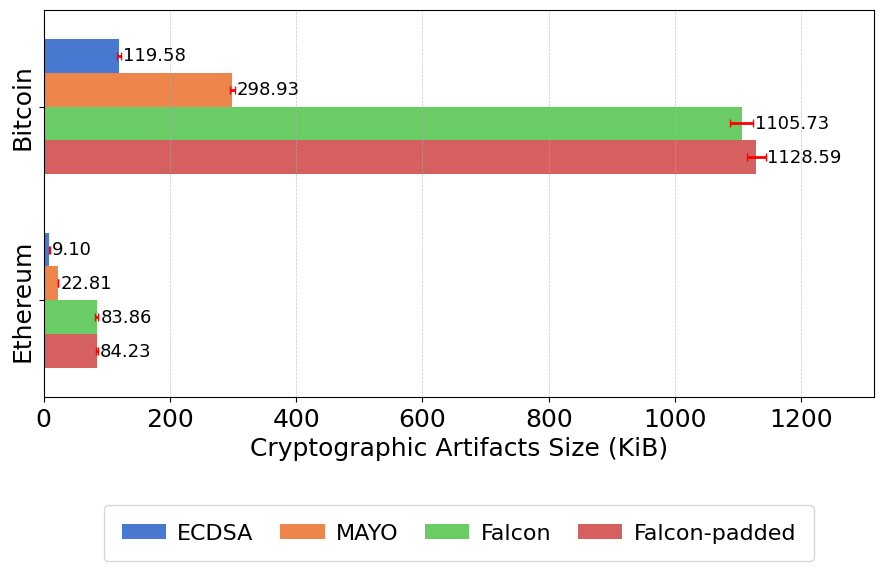

	Processing level 3 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-384'}, {'algorithm': 'mayo', 'variant': 'MAYO-3'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Saved: results-bcra/paper_graphics/sim_scenario3_level-3.pdf


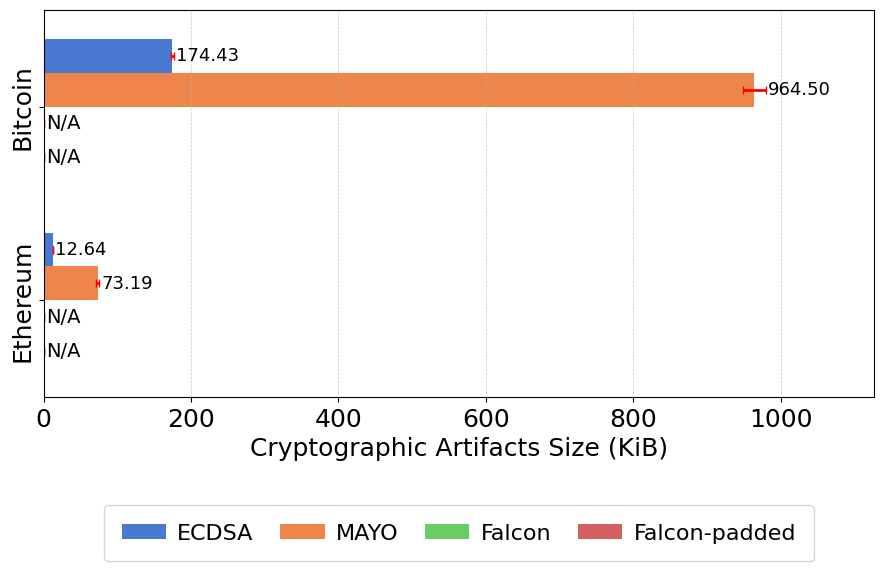

	Processing level 5 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-521'}, {'algorithm': 'falcon', 'variant': 'Falcon-1024'}, {'algorithm': 'falcon-padded', 'variant': 'Falcon-padded-1024'}, {'algorithm': 'mayo', 'variant': 'MAYO-5'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Saved: results-bcra/paper_graphics/sim_scenario3_level-5.pdf


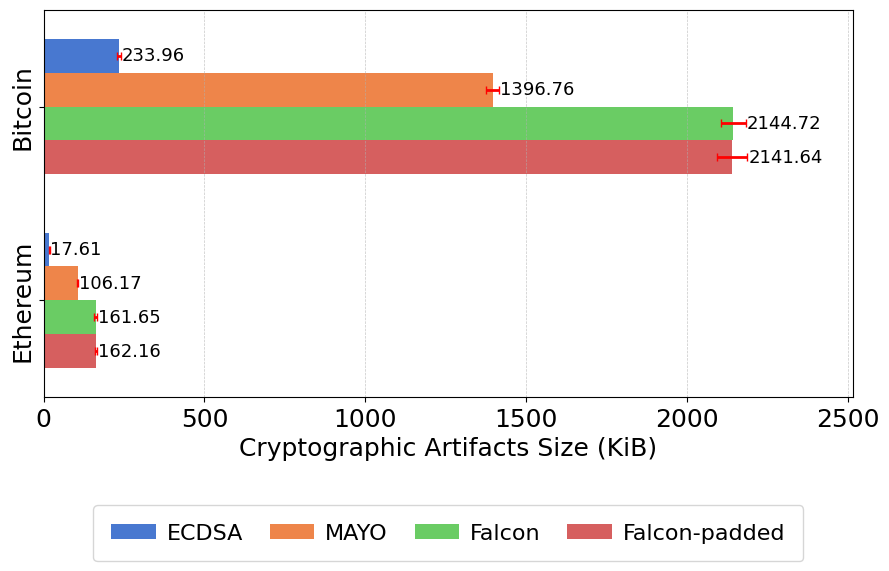

In [24]:
all_algorithms = ALGORITHMS
levels = [1, 3, 5]

sign = """ecdsa
   mayo 
   falcon
   falcon-padded
    """
sign_list = [s.strip() for s in sign.split()]

print("All algorithms loaded:", list(all_algorithms.keys()))
filtered_algorithms = filter_algorithms(all_algorithms, sign_list, levels)
print("Filtered algorithms:", filtered_algorithms)
combined_mechanisms = {}
for algorithm in filtered_algorithms.values():
    combined_mechanisms.update(algorithm)

print("Combined mechanisms:", combined_mechanisms)

for r in results.keys():
    print(f"Processing results for {r}: {results[r].keys()}")  


print("All algorithms loaded:", list(all_algorithms.keys()))

for m in ["scenario1", "scenario2", "scenario3"]:
    df_ethereum = results[m]["blocksim-model-2-mean-std"]
    df_bitcoin = results[m]["blocksim-model-1-mean-std"]
    variants_by_level = get_variants_by_level(df_ethereum, combined_mechanisms)
    print("Variants by level:", variants_by_level)
    dfs = []
    
    for level, variants in variants_by_level.items():
        print(f"\tProcessing level {level} with variants: {variants}")
        variant_to_algorithm = {v["variant"]: v["algorithm"] for v in variants}
        variant_names = [v["variant"] for v in variants]
        
        # Copy the subsets of each network.
        df_ethereum_subset = df_ethereum.loc[variant_names].copy()
        df_bitcoin_subset = df_bitcoin.loc[variant_names].copy()

        # Map the algorithms
        df_ethereum_subset["algorithm"] = df_ethereum_subset.index.map(variant_to_algorithm)
        
        # 1. Rename the Ethereum columns to avoid conflicts.
        df_combined = df_ethereum_subset.rename(columns={
            "mean_artifacts_size": "eth_mean_size",
            "std_artifacts_size": "eth_std_size"
        })
        
        # 2. Get the Bitcoin columns with unique names.
        df_combined["btc_mean_size"] = df_bitcoin_subset["mean_artifacts_size"]
        df_combined["btc_std_size"] = df_bitcoin_subset["std_artifacts_size"]
        
        # Add missing algorithms (N/A) BEFORE creating algorithm2
        for s in sign_list:
            if s not in df_combined["algorithm"].values:
                new_row = {col: 0.0 for col in df_combined.columns}
                new_row["algorithm"] = s
                new_row["variant"] = f"N/A-{s}"
                new_row_df = pd.DataFrame([new_row]).set_index("variant")
                df_combined = pd.concat([df_combined, new_row_df])
         
        # Create algorithm2
        df_combined["algorithm2"] = df_combined.apply(
            lambda x: f"{x['algorithm']}\n({x.name})" if "N/A" not in str(x.name) 
                     else x['algorithm'],
            axis=1
        )

        # Sort and categorize
        df_combined["algorithm"] = pd.Categorical(
            df_combined["algorithm"], 
            categories=sign_list, 
            ordered=True
        )
        df_combined = df_combined.sort_values("algorithm")
        
        # 3. Updates the columns that will be passed to the plotter.
        plot_columns = [
            ("eth_mean_size", "eth_std_size", "Ethereum"),
            ("btc_mean_size", "btc_std_size", "Bitcoin"),
        ]

        xscale = "linear"
        xlabel = "Cryptographic Artifacts Size (KiB)"
        yticklabels = "algorithm" 
        width = 0.7
        ylabel = None
        save_formats = ["pdf"]
        xlims={1:None, 3:None, 5:None}
        
        # 4. Call the plotter with the combined DataFrame and the correct columns.
        plot_horizontal_multiple_inverted(
            dfs=[df_combined],
            columns=plot_columns,
            graphics_directory=OUTPUT_DIR,
            values_offset=3,
            error_offset=0,
            levels=levels,
            figsize=(9, 6),
            xscale=xscale,
            xlabel=xlabel,
            xlim=(0, xlims[level]),
            yticklabels=yticklabels,
            width=width,
            titles=None,
            ylabel=ylabel,
            show_graph=True,
            show_values=True,
            show_errors=True,
            show_legend=True,
            save_formats=save_formats,
            file_name=f"sim_{m}_level-{level}",
            pallet_start=0,
            legend_location="lower right" 
        )